# Report Figures

Generates and saves all six figures recommended for the MECH0107 CW2 report, styled with `scienceplots`.

In [2]:
import numpy as np
import pandas as pd
import joblib
import time
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from scipy.stats import qmc
from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, Matern, RationalQuadratic
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots

plt.style.use(['science', 'no-latex'])

# Paths (notebook lives in notebooks/, data/models/results are siblings)
ROOT      = Path('..')
DATA_PATH = ROOT / 'data' / 'TrainingData_256.csv'
MODEL_DIR = ROOT / 'models'
RES_DIR   = ROOT / 'results'
FIG_DIR   = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Colour-blind safe palette (Wong 2011) — works in greyscale too
CB = {
    'blue':   '#0072B2',
    'orange': '#D55E00',
    'green':  '#009E73',
    'sky':    '#56B4E9',
    'yellow': '#F0E442',
    'grey':   '#999999',
    'black':  '#000000',
}

SAVE_KW = dict(dpi=300, bbox_inches='tight')
print('Setup complete.')

Setup complete.


## Shared Data & Models

In [3]:
# ── Training data ──────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
X  = df[['W1', 'W2', 'R', 't']].values
y  = df['MaxVonMisesStress_MPa'].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

# ── GPR model ──────────────────────────────────────────────────────────────
gpr_pipe   = joblib.load(MODEL_DIR / 'gpr_best_pipeline.pkl')
gpr_scaler = gpr_pipe.named_steps['scaler']
gpr_model  = gpr_pipe.named_steps['gpr']

X_test_gpr_s      = gpr_scaler.transform(X_test_raw)
y_pred_gpr, y_std = gpr_model.predict(X_test_gpr_s, return_std=True)

# ── NN model ───────────────────────────────────────────────────────────────
nn_bundle = joblib.load(MODEL_DIR / 'nn_scalers.joblib')
nn_fs     = nn_bundle['feature_scaler']
nn_ts     = nn_bundle['target_scaler']
arch      = nn_bundle['arch']   # {'hidden_layers': (128,128,128,128), 'activation': 'sine', 'dropout': 0.0}

def build_mlp(n_inputs=4, hidden_layers=(128,128,128,128), activation='sine', dropout=0.0):
    act_map = {'relu': nn.ReLU(), 'ELU': nn.ELU(), 'tanh': nn.Tanh(),
               'sine': nn.SiLU(), 'sigmoid': nn.Sigmoid(), 'soft_plus': nn.Softplus()}
    layers, prev = [], n_inputs
    for h in hidden_layers:
        layers += [nn.Linear(prev, h), act_map[activation]]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        prev = h
    layers.append(nn.Linear(prev, 1))
    return nn.Sequential(*layers)

nn_model = build_mlp(**arch)
nn_model.load_state_dict(torch.load(MODEL_DIR / 'nn_surrogate.pt', weights_only=True))
nn_model.eval()

X_test_nn_s = nn_fs.transform(X_test_raw)
with torch.no_grad():
    y_pred_nn_s = nn_model(torch.FloatTensor(X_test_nn_s)).numpy().flatten()
y_pred_nn = nn_ts.inverse_transform(y_pred_nn_s.reshape(-1, 1)).flatten()

# ── NN retraining for loss history ─────────────────────────────────────────
X_sub_raw, X_val_raw, y_sub_raw, y_val_raw = train_test_split(
    X_train_raw, y_train_raw, test_size=0.15, random_state=SEED)

final_fs = StandardScaler().fit(X_sub_raw)
final_ts = StandardScaler().fit(y_sub_raw.reshape(-1, 1))
X_sub_s  = final_fs.transform(X_sub_raw)
X_val_s  = final_fs.transform(X_val_raw)
y_sub_s  = final_ts.transform(y_sub_raw.reshape(-1, 1)).flatten()
y_val_s  = final_ts.transform(y_val_raw.reshape(-1, 1)).flatten()

torch.manual_seed(SEED)
retrain_model = build_mlp(**arch)
optim     = torch.optim.Adam(retrain_model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()
loader    = DataLoader(TensorDataset(torch.FloatTensor(X_sub_s),
                                     torch.FloatTensor(y_sub_s).view(-1, 1)),
                       batch_size=16, shuffle=True)
Xv_t = torch.FloatTensor(X_val_s)
yv_t = torch.FloatTensor(y_val_s).view(-1, 1)

history = {'train': [], 'val': []}
best_val, best_state, patience_counter = float('inf'), None, 0

for epoch in range(500):
    retrain_model.train()
    batch_losses = []
    for xb, yb in loader:
        optim.zero_grad()
        l = loss_fn(retrain_model(xb), yb)
        l.backward(); optim.step()
        batch_losses.append(l.item())
    retrain_model.eval()
    with torch.no_grad():
        val_l = loss_fn(retrain_model(Xv_t), yv_t).item()
    history['train'].append(float(np.mean(batch_losses)))
    history['val'].append(val_l)
    if val_l < best_val:
        best_val = val_l
        best_state = {k: v.clone() for k, v in retrain_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 30:
            break

best_epoch = int(np.argmin(history['val']))
print(f'NN retrained: {epoch+1} epochs, best val epoch = {best_epoch+1}')

# ── Experiment CSVs ────────────────────────────────────────────────────────
exp = {i: pd.read_csv(RES_DIR / f'exp{i}_{n}.csv')
       for i, n in enumerate(['activation','depth','width','regularisation',
                               'optimiser','lr','batch','n_samples'], 1)}

# ── Pareto data ────────────────────────────────────────────────────────────
pf_gpr = pd.read_csv(RES_DIR / 'pareto_front_gpr.csv')
pa_gpr = pd.read_csv(RES_DIR / 'pareto_all_gpr.csv')
pf_nn  = pd.read_csv(RES_DIR / 'pareto_front_nn.csv')
pa_nn  = pd.read_csv(RES_DIR / 'pareto_all_nn.csv')

print('All data loaded.')

NN retrained: 191 epochs, best val epoch = 161
All data loaded.


## Figure 1 — Sampling Method Comparison

*Section 1 — Data Sampling.* Justifies the choice of LHS over random and Sobol sampling.

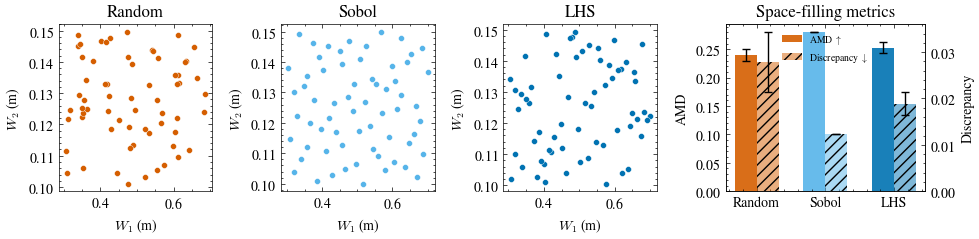

Saved fig_report_1_sampling.png


In [12]:
N, D, REPS = 64, 4, 50

def amd(s):
    d = cdist(s, s); np.fill_diagonal(d, np.inf)
    return float(np.mean(np.min(d, axis=1)))

def disc(s):
    return float(qmc.discrepancy(s, method='L2-star'))

# Generate stats over multiple realisations
rand_amd, rand_disc = [], []
for i in range(REPS):
    s = np.random.default_rng(SEED + i).random((N, D))
    rand_amd.append(amd(s)); rand_disc.append(disc(s))

lhs_amd, lhs_disc = [], []
for i in range(REPS):
    s = qmc.LatinHypercube(d=D, seed=SEED + i).random(N)
    lhs_amd.append(amd(s)); lhs_disc.append(disc(s))

sobol_pts  = qmc.Sobol(d=D).random(N)
sobol_amd  = amd(sobol_pts)
sobol_disc = disc(sobol_pts)

# Representative scatter points for visualisation
LO = np.array([0.30, 0.10, 0.03, 0.01])
HI = np.array([0.70, 0.15, 0.07, 0.02])
scale = lambda p: p * (HI - LO) + LO

rand_pts = scale(np.random.default_rng(SEED).random((N, D)))
sobol_sc = scale(sobol_pts)
lhs_pts  = scale(qmc.LatinHypercube(d=D, seed=SEED).random(N))

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(10, 2.6),
                         gridspec_kw={'width_ratios': [1, 1, 1, 1.3]})

sk = dict(s=18, linewidths=0.3, edgecolors='white')
for ax, pts, title, col in [
    (axes[0], rand_pts,  'Random',  CB['orange']),
    (axes[1], sobol_sc,  'Sobol',   CB['sky']),
    (axes[2], lhs_pts,   'LHS',     CB['blue']),
]:
    ax.scatter(pts[:, 0], pts[:, 1], color=col, **sk)
    ax.set_xlabel('$W_1$ (m)'); ax.set_ylabel('$W_2$ (m)')
    ax.set_title(title)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))

# Metrics bar chart
ax = axes[3]
x  = np.array([0, 1, 2])
w  = 0.32
a_means = [np.mean(rand_amd), sobol_amd,  np.mean(lhs_amd)]
a_stds  = [np.std(rand_amd),  0.,         np.std(lhs_amd)]
d_means = [np.mean(rand_disc), sobol_disc, np.mean(lhs_disc)]
d_stds  = [np.std(rand_disc),  0.,         np.std(lhs_disc)]
cols    = [CB['orange'], CB['sky'], CB['blue']]

ax.bar(x - w/2, a_means, w, yerr=a_stds, capsize=3,
       color=cols, label='AMD $\\uparrow$', alpha=0.9)
ax2 = ax.twinx(); ax2.grid(False)
ax2.bar(x + w/2, d_means, w, yerr=d_stds, capsize=3,
        color=cols, hatch='///', alpha=0.5, label='Discrepancy $\\downarrow$')
ax.set_xticks(x); ax.set_xticklabels(['Random', 'Sobol', 'LHS'])
ax.set_ylabel('AMD')
ax2.set_ylabel('Discrepancy')
ax.set_title('Space-filling metrics')
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=7, loc='upper center')

# fig.suptitle('Sampling method comparison (64 points, 4D design space)', y=1.03)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_report_1_sampling.png', **SAVE_KW)
plt.show()
print('Saved fig_report_1_sampling.png')

## Figure 2 — GPR Kernel Comparison

*Section 1 — GPR design choices.* (a) CV MAPE for each kernel justifies Matérn 2.5. (b) ARD length scales show which design variables drive the stress response.

/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 37 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


  RBF: 0.732 +/- 0.063 %


/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/data-

  Matern 1.5: 0.335 +/- 0.067 %


/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 16 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/op

  Matern 2.5: 0.259 +/- 0.047 %


/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 35 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 34 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  

  Rat. Quad.: 0.558 +/- 0.119 %


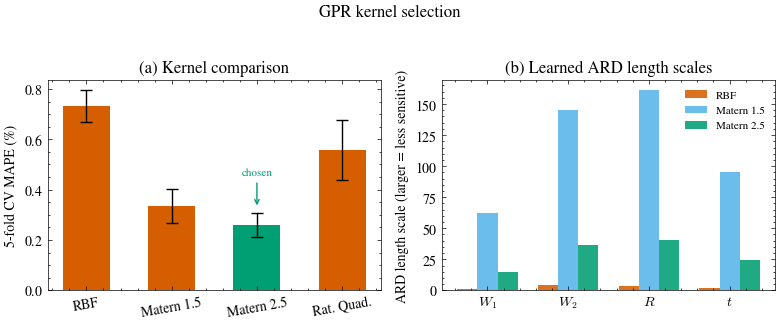

Saved fig_report_2_gpr_kernels.png


In [5]:
kernels = {
    'RBF':         C(1.0,(1e-3,1e3)) * RBF([1.]*4, (1e-3,1e3)),
    'Matern 1.5':  C(1.0,(1e-3,1e3)) * Matern([1.]*4, (1e-3,1e3), nu=1.5),
    'Matern 2.5':  C(1.0,(1e-3,1e3)) * Matern([1.]*4, (1e-3,1e3), nu=2.5),
    'Rat. Quad.':  C(1.0,(1e-3,1e3)) * RationalQuadratic(length_scale=1.0,
                       length_scale_bounds=(1e-3,1e3)),
}
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_mean, cv_std, ls_dict = {}, {}, {}
for name, kern in kernels.items():
    pipe = Pipeline([('sc', StandardScaler()),
                     ('gpr', GaussianProcessRegressor(kernel=kern,
                             n_restarts_optimizer=10, normalize_y=True,
                             random_state=SEED))])
    sc = cross_val_score(pipe, X_train_raw, y_train_raw, cv=kf,
                         scoring='neg_mean_absolute_percentage_error')
    cv_mean[name] = -100 * sc.mean()
    cv_std[name]  =  100 * sc.std()
    pipe.fit(X_train_raw, y_train_raw)
    ls_dict[name] = np.atleast_1d(pipe.named_steps['gpr'].kernel_.k2.length_scale)
    print(f'  {name}: {cv_mean[name]:.3f} +/- {cv_std[name]:.3f} %')

names = list(kernels.keys())
best  = min(names, key=lambda n: cv_mean[n])
bar_cols = [CB['green'] if n == best else CB['orange'] for n in names]

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(8, 3.2))

# (a) Kernel MAPE
bars = ax_l.bar(names, [cv_mean[n] for n in names],
                yerr=[cv_std[n] for n in names],
                color=bar_cols, capsize=4, width=0.55)
ax_l.set_ylabel('5-fold CV MAPE (%)')
ax_l.set_title('(a) Kernel comparison')
ax_l.tick_params(axis='x', rotation=10)
best_idx = names.index(best)
ax_l.annotate('chosen', xy=(best_idx, cv_mean[best] + cv_std[best] + 0.02),
              ha='center', fontsize=8, color=CB['green'],
              arrowprops=dict(arrowstyle='->', color=CB['green']),
              xytext=(best_idx, cv_mean[best] + cv_std[best] + 0.15))

# (b) ARD length scales — only kernels whose fitted k2.length_scale is a 4-vector
# (RationalQuadratic uses a shared scalar, so it is excluded automatically)
feats     = ['$W_1$', '$W_2$', '$R$', '$t$']
ard_names = [n for n in names if len(ls_dict[n]) == 4]
pal       = [CB['orange'], CB['sky'], CB['green']]
x_pos     = np.arange(4)
bw        = 0.25
for k, (n, col) in enumerate(zip(ard_names, pal)):
    off = (k - len(ard_names) / 2 + 0.5) * bw
    ax_r.bar(x_pos + off, ls_dict[n], bw, label=n, color=col, alpha=0.88)
ax_r.set_xticks(x_pos); ax_r.set_xticklabels(feats)
ax_r.set_ylabel('ARD length scale (larger = less sensitive)')
ax_r.set_title('(b) Learned ARD length scales')
ax_r.legend(fontsize=8)

fig.suptitle('GPR kernel selection', y=1.03)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_report_2_gpr_kernels.png', **SAVE_KW)
plt.show()
print('Saved fig_report_2_gpr_kernels.png')

## Figure 3 — NN Hyperparameter Dashboard

*Section 1 — NN design choices.* All 8 sequential experiments in one figure. Reads directly from saved CSVs.

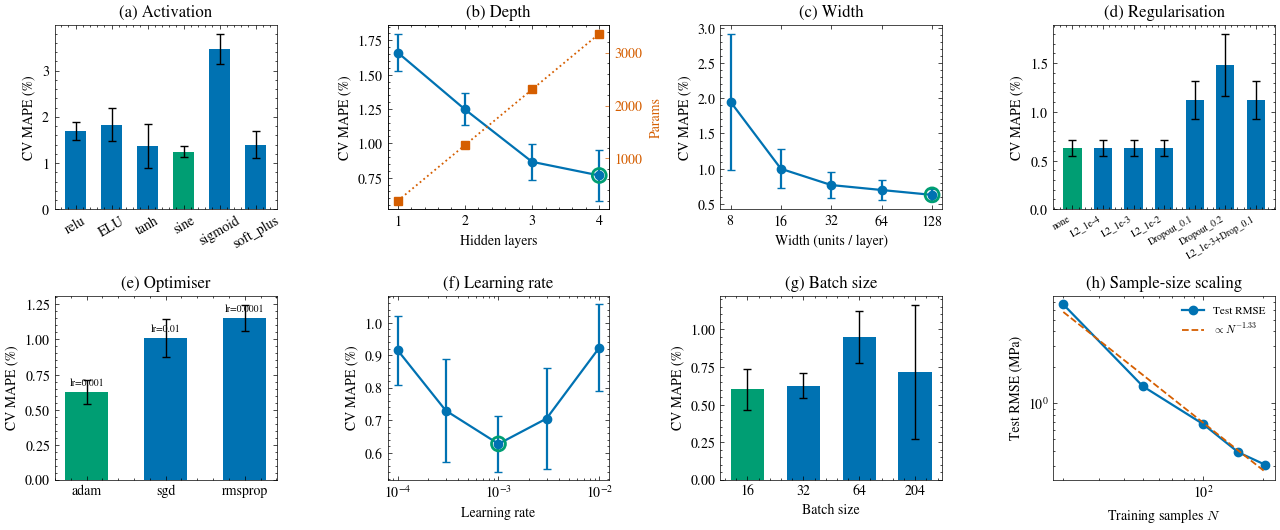

Saved fig_report_3_nn_hparams.png


In [13]:
import matplotlib as mpl

def highlight(vals, best_fn=min):
    return int(np.argmin(vals)) if best_fn is min else int(np.argmax(vals))

fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
# fig.suptitle('NN architecture & hyperparameter study (5-fold CV MAPE unless noted)', y=1.02)

# (a) Activation
ax = axes[0, 0]
idx = highlight(exp[1]['mape_mean'])
cols = [CB['green'] if k == idx else CB['blue'] for k in range(len(exp[1]))]
ax.bar(exp[1]['activation'], exp[1]['mape_mean'], yerr=exp[1]['mape_std'],
       color=cols, capsize=3, width=0.6)
ax.set_ylabel('CV MAPE (%)'); ax.set_title('(a) Activation')
ax.tick_params(axis='x', rotation=30)

# (b) Depth — dual axis
ax = axes[0, 1]
ax.errorbar(exp[2]['depth'], exp[2]['mape_mean'], yerr=exp[2]['mape_std'],
            marker='o', color=CB['blue'], capsize=3, lw=1.6)
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(exp[2]['depth'], exp[2]['n_params'], 's:', color=CB['orange'], lw=1.3)
ax2.set_ylabel('Params', color=CB['orange'])
ax2.tick_params(axis='y', colors=CB['orange'])
idx = highlight(exp[2]['mape_mean'])
ax.scatter([exp[2]['depth'].iloc[idx]], [exp[2]['mape_mean'].iloc[idx]],
           s=100, facecolor='none', edgecolor=CB['green'], lw=2, zorder=5)
ax.set_xlabel('Hidden layers'); ax.set_ylabel('CV MAPE (%)')
ax.set_title('(b) Depth'); ax.set_xticks(exp[2]['depth'])

# (c) Width
ax = axes[0, 2]
ax.errorbar(exp[3]['width'], exp[3]['mape_mean'], yerr=exp[3]['mape_std'],
            marker='o', color=CB['blue'], capsize=3, lw=1.6)
idx = highlight(exp[3]['mape_mean'])
ax.scatter([exp[3]['width'].iloc[idx]], [exp[3]['mape_mean'].iloc[idx]],
           s=100, facecolor='none', edgecolor=CB['green'], lw=2, zorder=5)
ax.set_xscale('log', base=2)
ax.set_xlabel('Width (units / layer)'); ax.set_ylabel('CV MAPE (%)')
ax.set_title('(c) Width')
ax.set_xticks(exp[3]['width'])
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())

# (d) Regularisation
ax = axes[0, 3]
idx = highlight(exp[4]['mape_mean'])
cols = [CB['green'] if k == idx else CB['blue'] for k in range(len(exp[4]))]
ax.bar(range(len(exp[4])), exp[4]['mape_mean'], yerr=exp[4]['mape_std'],
       color=cols, capsize=3, width=0.6)
ax.set_xticks(range(len(exp[4])))
ax.set_xticklabels(exp[4]['scheme'], rotation=30, ha='right', fontsize=7)
ax.set_ylabel('CV MAPE (%)'); ax.set_title('(d) Regularisation')

# (e) Optimiser
ax = axes[1, 0]
idx = highlight(exp[5]['mape_mean'])
cols = [CB['green'] if k == idx else CB['blue'] for k in range(len(exp[5]))]
bars = ax.bar(exp[5]['optimiser'], exp[5]['mape_mean'], yerr=exp[5]['mape_std'],
              color=cols, capsize=3, width=0.55)
for rect, lr in zip(bars, exp[5]['best_lr']):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.04,
            f'lr={lr:g}', ha='center', fontsize=7)
ax.set_ylabel('CV MAPE (%)'); ax.set_title('(e) Optimiser')

# (f) Learning rate
ax = axes[1, 1]
ax.errorbar(exp[6]['lr'], exp[6]['mape_mean'], yerr=exp[6]['mape_std'],
            marker='o', color=CB['blue'], capsize=3, lw=1.6)
idx = highlight(exp[6]['mape_mean'])
ax.scatter([exp[6]['lr'].iloc[idx]], [exp[6]['mape_mean'].iloc[idx]],
           s=100, facecolor='none', edgecolor=CB['green'], lw=2, zorder=5)
ax.set_xscale('log')
ax.set_xlabel('Learning rate'); ax.set_ylabel('CV MAPE (%)')
ax.set_title('(f) Learning rate')

# (g) Batch size
ax = axes[1, 2]
idx = highlight(exp[7]['mape_mean'])
cols = [CB['green'] if k == idx else CB['blue'] for k in range(len(exp[7]))]
ax.bar([str(b) for b in exp[7]['batch_size']], exp[7]['mape_mean'],
       yerr=exp[7]['mape_std'], color=cols, capsize=3, width=0.6)
ax.set_xlabel('Batch size'); ax.set_ylabel('CV MAPE (%)')
ax.set_title('(g) Batch size')

# (h) Sample-size scaling (power law on test RMSE)
ax = axes[1, 3]
n    = exp[8]['n_samples'].values.astype(float)
rmse = exp[8]['test_rmse'].values.astype(float)
ax.loglog(n, rmse, 'o-', color=CB['blue'], lw=1.6, label='Test RMSE')
coef = np.polyfit(np.log(n), np.log(rmse), 1)
n_fit = np.linspace(n.min(), n.max(), 80)
ax.loglog(n_fit, np.exp(coef[1]) * n_fit**coef[0], '--', color=CB['orange'],
          lw=1.3, label=f'$\\propto N^{{{coef[0]:.2f}}}$')
ax.set_xlabel('Training samples $N$'); ax.set_ylabel('Test RMSE (MPa)')
ax.set_title('(h) Sample-size scaling')
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_report_3_nn_hparams.png', **SAVE_KW)
plt.show()
print('Saved fig_report_3_nn_hparams.png')

## Figure 4 — GPR Error Evaluation

*Section 2 — GPR Results.* (a) Parity plot with 95% CI error bars coloured by residual magnitude. (b) Sorted test predictions with confidence band — demonstrates that uncertainty is well-calibrated.

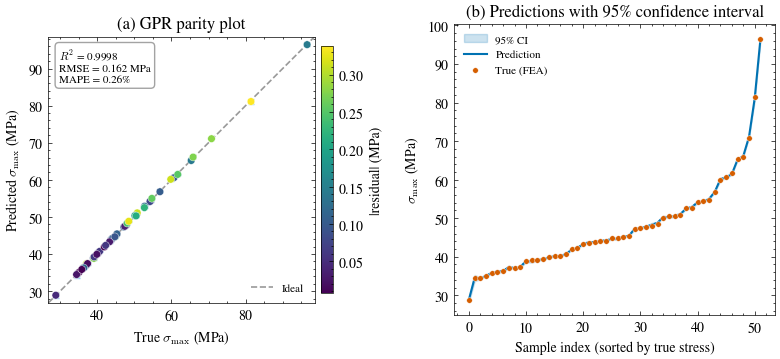

Saved fig_report_4_gpr_errors.png


In [10]:
err_gpr = y_pred_gpr - y_test_raw
rmse_g  = float(np.sqrt(np.mean(err_gpr**2)))
mape_g  = float(np.mean(np.abs(err_gpr / y_test_raw)) * 100)
r2_g    = 1. - float(np.sum(err_gpr**2) / np.sum((y_test_raw - y_test_raw.mean())**2))

fig, (ax_p, ax_ci) = plt.subplots(1, 2, figsize=(8, 3.8))

# (a) Parity
lims = [min(y_test_raw.min(), y_pred_gpr.min()) - 2,
        max(y_test_raw.max(), y_pred_gpr.max()) + 2]
ax_p.errorbar(y_test_raw, y_pred_gpr, yerr=1.96 * y_std,
              fmt='none', ecolor=CB['sky'], elinewidth=0.7, capsize=2, alpha=0.6)
sc = ax_p.scatter(y_test_raw, y_pred_gpr, c=np.abs(err_gpr),
                  cmap='viridis', s=30, zorder=3, linewidths=0.3, edgecolors='white')
ax_p.plot(lims, lims, '--', color=CB['grey'], lw=1.2, label='Ideal')
ax_p.set_xlim(lims); ax_p.set_ylim(lims); ax_p.set_aspect('equal')
ax_p.set_xlabel('True $\\sigma_{\\mathrm{max}}$ (MPa)')
ax_p.set_ylabel('Predicted $\\sigma_{\\mathrm{max}}$ (MPa)')
ax_p.set_title('(a) GPR parity plot')
ax_p.text(0.04, 0.96,
          f'$R^2$ = {r2_g:.4f}\nRMSE = {rmse_g:.3f} MPa\nMAPE = {mape_g:.2f}%',
          transform=ax_p.transAxes, va='top', fontsize=8,
          bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                    edgecolor=CB['grey'], alpha=0.9))
ax_p.legend(loc='lower right', fontsize=8)
plt.colorbar(sc, ax=ax_p, label='|residual| (MPa)', shrink=0.85, pad=0.02)

# (b) Sorted CI
si = np.argsort(y_test_raw)
xi = np.arange(len(y_test_raw))
ax_ci.fill_between(xi,
                   y_pred_gpr[si] - 1.96 * y_std[si],
                   y_pred_gpr[si] + 1.96 * y_std[si],
                   alpha=0.2, color=CB['blue'], label='95% CI')
ax_ci.plot(xi, y_pred_gpr[si], color=CB['blue'], lw=1.5, label='Prediction')
ax_ci.scatter(xi, y_test_raw[si], s=16, color=CB['orange'],
              linewidths=0.3, edgecolors='white', zorder=3, label='True (FEA)')
ax_ci.set_xlabel('Sample index (sorted by true stress)')
ax_ci.set_ylabel('$\\sigma_{\\mathrm{max}}$ (MPa)')
ax_ci.set_title('(b) Predictions with 95% confidence interval')
ax_ci.legend(fontsize=8)

# fig.suptitle('GPR surrogate — error evaluation on held-out test set ($n = 52$)', y=1.03)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_report_4_gpr_errors.png', **SAVE_KW)
plt.show()
print('Saved fig_report_4_gpr_errors.png')

## Figure 5 — NN Error Evaluation

*Section 2 — NN Results.* (a) NN parity plot. (b) Training and validation loss curves confirming convergence and no overfitting.

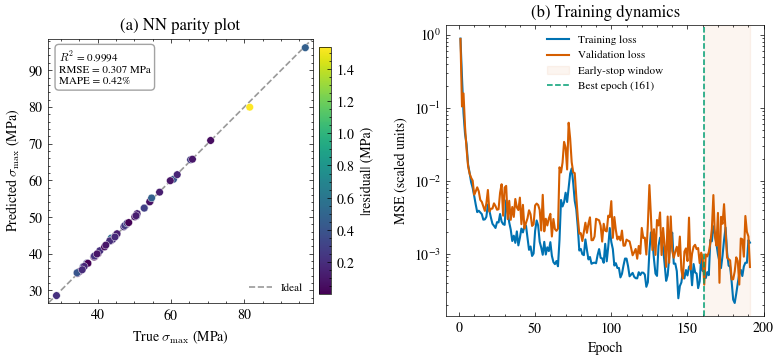

Saved fig_report_5_nn_errors.png


In [8]:
err_nn = y_pred_nn - y_test_raw
rmse_n = float(np.sqrt(np.mean(err_nn**2)))
mape_n = float(np.mean(np.abs(err_nn / y_test_raw)) * 100)
r2_n   = 1. - float(np.sum(err_nn**2) / np.sum((y_test_raw - y_test_raw.mean())**2))

train_l = np.array(history['train'])
val_l   = np.array(history['val'])
epochs  = np.arange(1, len(val_l) + 1)
stop_ep = len(val_l)

fig, (ax_p, ax_lc) = plt.subplots(1, 2, figsize=(8, 3.8))

# (a) Parity
lims = [min(y_test_raw.min(), y_pred_nn.min()) - 2,
        max(y_test_raw.max(), y_pred_nn.max()) + 2]
sc = ax_p.scatter(y_test_raw, y_pred_nn, c=np.abs(err_nn),
                  cmap='viridis', s=30, zorder=3, linewidths=0.3, edgecolors='white')
ax_p.plot(lims, lims, '--', color=CB['grey'], lw=1.2, label='Ideal')
ax_p.set_xlim(lims); ax_p.set_ylim(lims); ax_p.set_aspect('equal')
ax_p.set_xlabel('True $\\sigma_{\\mathrm{max}}$ (MPa)')
ax_p.set_ylabel('Predicted $\\sigma_{\\mathrm{max}}$ (MPa)')
ax_p.set_title('(a) NN parity plot')
ax_p.text(0.04, 0.96,
          f'$R^2$ = {r2_n:.4f}\nRMSE = {rmse_n:.3f} MPa\nMAPE = {mape_n:.2f}%',
          transform=ax_p.transAxes, va='top', fontsize=8,
          bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                    edgecolor=CB['grey'], alpha=0.9))
ax_p.legend(loc='lower right', fontsize=8)
plt.colorbar(sc, ax=ax_p, label='|residual| (MPa)', shrink=0.85, pad=0.02)

# (b) Loss curves
ax_lc.plot(epochs, train_l, color=CB['blue'], lw=1.5, label='Training loss')
ax_lc.plot(epochs, val_l,   color=CB['orange'], lw=1.5, label='Validation loss')
ax_lc.axvspan(best_epoch + 1, stop_ep, color=CB['orange'], alpha=0.06,
              label='Early-stop window')
ax_lc.axvline(best_epoch + 1, color=CB['green'], ls='--', lw=1.1,
              label=f'Best epoch ({best_epoch + 1})')
ax_lc.set_yscale('log')
ax_lc.set_xlabel('Epoch')
ax_lc.set_ylabel('MSE (scaled units)')
ax_lc.set_title('(b) Training dynamics')
ax_lc.legend(fontsize=8)

# fig.suptitle('NN surrogate — error evaluation on held-out test set ($n = 52$)', y=1.03)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_report_5_nn_errors.png', **SAVE_KW)
plt.show()
print('Saved fig_report_5_nn_errors.png')

## Figure 6 — Pareto Front Comparison

*Section 2 — Results.* GPR and NN Pareto fronts side-by-side and overlaid. Covers the optimisation results requirement for both models in one figure.

/var/folders/lq/1f0d05w114x6x06k0hn90f0c0000gn/T/ipykernel_92391/2468909378.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


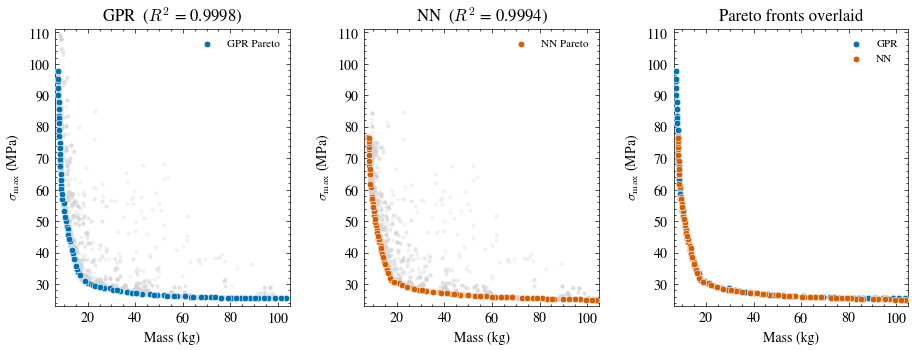

Saved fig_report_6_pareto.png


In [11]:
xlim = (min(pa_gpr.mass_kg.min(), pa_nn.mass_kg.min()) - 1,
        max(pa_gpr.mass_kg.max(), pa_nn.mass_kg.max()) + 1)
ylim = (min(pa_gpr.stress_mpa.min(), pa_nn.stress_mpa.min()) - 2,
        max(pa_gpr.stress_mpa.max(), pa_nn.stress_mpa.max()) + 2)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6),
                         gridspec_kw={'wspace': 0.32})

sub_kw   = dict(c='lightgray', alpha=0.3, s=8, linewidths=0)
front_kw = dict(s=22, linewidths=0.4, edgecolors='white', zorder=3)

# GPR panel
axes[0].scatter(pa_gpr.mass_kg, pa_gpr.stress_mpa, **sub_kw)
axes[0].scatter(pf_gpr.mass_kg, pf_gpr.stress_mpa,
                color=CB['blue'], label='GPR Pareto', **front_kw)
axes[0].set_xlabel('Mass (kg)')
axes[0].set_ylabel('$\\sigma_{\\mathrm{max}}$ (MPa)')
axes[0].set_title(f'GPR  ($R^2$ = {r2_g:.4f})')
axes[0].legend(fontsize=8)
axes[0].set_xlim(xlim); axes[0].set_ylim(ylim)

# NN panel
axes[1].scatter(pa_nn.mass_kg, pa_nn.stress_mpa, **sub_kw)
axes[1].scatter(pf_nn.mass_kg, pf_nn.stress_mpa,
                color=CB['orange'], label='NN Pareto', **front_kw)
axes[1].set_xlabel('Mass (kg)')
axes[1].set_ylabel('$\\sigma_{\\mathrm{max}}$ (MPa)')
axes[1].set_title(f'NN  ($R^2$ = {r2_n:.4f})')
axes[1].legend(fontsize=8)
axes[1].set_xlim(xlim); axes[1].set_ylim(ylim)

# Overlay panel
gpr_s = pf_gpr.sort_values('mass_kg')
nn_s  = pf_nn.sort_values('mass_kg')
axes[2].plot(gpr_s.mass_kg, gpr_s.stress_mpa,
             color=CB['blue'], lw=1.3, alpha=0.6)
axes[2].scatter(pf_gpr.mass_kg, pf_gpr.stress_mpa,
                color=CB['blue'], label='GPR', **front_kw)
axes[2].plot(nn_s.mass_kg, nn_s.stress_mpa,
             color=CB['orange'], lw=1.3, alpha=0.6)
axes[2].scatter(pf_nn.mass_kg, pf_nn.stress_mpa,
                color=CB['orange'], label='NN', **front_kw)
axes[2].set_xlabel('Mass (kg)')
axes[2].set_ylabel('$\\sigma_{\\mathrm{max}}$ (MPa)')
axes[2].set_title('Pareto fronts overlaid')
axes[2].legend(fontsize=8)
axes[2].set_xlim(xlim); axes[2].set_ylim(ylim)

# fig.suptitle('NSGA-II shape optimisation — Pareto fronts', y=1.03)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_report_6_pareto.png', **SAVE_KW)
plt.show()
print('Saved fig_report_6_pareto.png')